In [1]:
import pandas as pd


df = pd.read_csv("dataset.csv")

df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [2]:
df.tail(1)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [3]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df[["Age","Fare"]].describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [7]:
df["Age"].fillna(df["Age"].median(),inplace=True)

# 
# df["Age"] = df["Age"].fillna(df["Age"].median())

#print
df["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [8]:
df["Age"].describe()

count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [9]:

df.drop(columns=["Ticket","PassengerId","Name","Cabin","Embarked"],inplace=True)

df["Sex"] = df["Sex"].map({"male":0,"female":1})

df =df.rename(columns={'Sex':'Gender'})

df

,Survived,Pclass,Gender,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250
3,1,1,1,35.0,1,0,53.1000
4,0,3,0,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000
887,1,1,1,19.0,0,0,30.0000
888,0,3,1,28.0,1,2,23.4500
889,1,1,0,26.0,0,0,30.0000


In [10]:
#EDA
#Elite women = 94
print(df["Gender"][((df["Gender"]==1) & (df["Pclass"] ==1))].count())

# Elite man = 122
print(df["Gender"][((df["Gender"]==0) & (df["Pclass"] ==1))].count())

94
122


In [11]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [12]:
top_payers = df.sort_values('Fare',ascending=False)
print("top payers : "+str(top_payers))


top payers :      Survived  Pclass  Gender   Age  SibSp  Parch      Fare
258         1       1       1  35.0      0      0  512.3292
737         1       1       0  35.0      0      0  512.3292
679         1       1       0  36.0      0      1  512.3292
88          1       1       1  23.0      3      2  263.0000
27          0       1       0  19.0      3      2  263.0000
..        ...     ...     ...   ...    ...    ...       ...
633         0       1       0  28.0      0      0    0.0000
413         0       2       0  28.0      0      0    0.0000
822         0       1       0  38.0      0      0    0.0000
732         0       2       0  28.0      0      0    0.0000
674         0       2       0  28.0      0      0    0.0000

[891 rows x 7 columns]


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


X_train,X_test,Y_train,Y_test  = train_test_split(df[["Age","Pclass","SibSp","Parch","Gender"]],df["Survived"],test_size=0.2,random_state=42)

model = RandomForestClassifier(n_estimators=50)
model.fit(X_train,Y_train)

model.predict(X=[[25,1,0,2,0]])

/Users/sdsys/Desktop/Files/AI-ML-Training-NCIT-6th-Sem-BCA-Students/07- Titanic Dataset/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

0.75177304964539

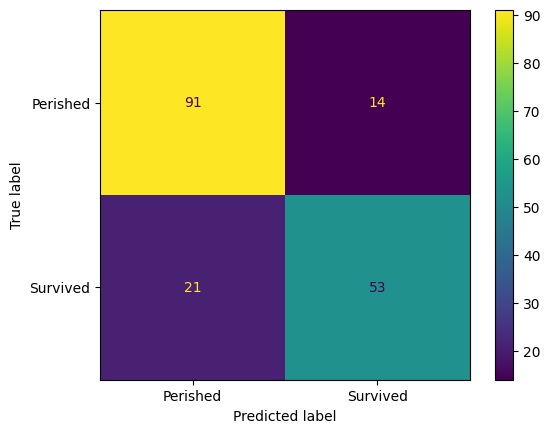

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,f1_score

cm = confusion_matrix(Y_test,model.predict(X_test))


ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Perished","Survived"]).plot()
f1_score(Y_test,model.predict(X_test))

